In [ ]:
# SHAZAM SHM MODELS 
# Este script aplica tres enfoques complementarios para analizar las mutaciones somáticas 
# en tu repertorio: primero calcula la carga mutacional global comparando cada secuencia 
# completa contra su germline, luego evalúa la distribución de mutaciones por 
# subregiones (CDR y FWR según definiciones IMGT) para distinguir entre regiones de unión
# y estructurales, y finalmente clasifica las mutaciones según propiedades fisicoquímicas
# de los aminoácidos (carga, polaridad, hidrofobicidad o volumen) para estimar su impacto
# funcional

In [2]:

library(shazam)
library(alakazam)
library(readr)
library(dplyr)


Loading required package: ggplot2

Warning message:
"replacing previous import 'S4Arrays::makeNindexFromArrayViewport' by 'DelayedArray::makeNindexFromArrayViewport' when loading 'SummarizedExperiment'"


To cite the SHazaM package in publications, please use:

  Gupta N, Vander Heiden J, Uduman M, Gadala-Maria D, Yaari G,
  Kleinstein S (2015). "Change-O: a toolkit for analyzing large-scale B
  cell immunoglobulin repertoire sequencing data." _Bioinformatics_,
  1-3. doi:10.1093/bioinformatics/btv359
  <https://doi.org/10.1093/bioinformatics/btv359>.

To cite the selection analysis methods, please use:

  Yaari G, Uduman M, Kleinstein S (2012). "Quantifying selection in
  high-throughput Immunoglobulin sequencing data sets." _Nucleic acids
  research_, *40*(17), e134. doi:10.1093/nar/gks457
  <https://doi.org/10.1093/nar/gks457>.

To cite the HH_S5F model and the targeting model generation methods,
please use:

  Yaari G, Vander Heiden J, Uduman M, Gadala-Maria D, Gupta N, Stern J,
  

In [4]:
# MUTATION ANALYSIS SHAZAM
# 1. Cargar tu archivo
archivo_clones <- "../data/output/repertorio_A_insilico_30_seqs_clone-pass.tsv"
clones <- read_tsv(archivo_clones) %>%
  mutate(sample_id = "repertorio_simulado")

# 2. Mutaciones globales (toda la secuencia)
mut_global <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=NULL,   # toda la secuencia
  frequency=TRUE
)

# 3. Mutaciones por subregión (CDR/FWR según IMGT)
mut_regions <- observedMutations(
  clones,
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment",
  regionDefinition=IMGT_V_BY_REGIONS,   # esquema IMGT con CDR/FWR
  frequency=TRUE
)


# Mutaciones globales
db_all <- mut_global[, c("mu_freq_seq_r","mu_freq_seq_s")]

# Mutaciones en CDR1 y CDR2 (R y S)
cdr_mutations <- mut_regions[, c("mu_freq_cdr1_r","mu_freq_cdr1_s",
                                 "mu_freq_cdr2_r","mu_freq_cdr2_s")]

# Mutaciones en FWR1–3 (R y S)
fwr_mutations <- mut_regions[, c("mu_freq_fwr1_r","mu_freq_fwr1_s",
                                 "mu_freq_fwr2_r","mu_freq_fwr2_s",
                                 "mu_freq_fwr3_r","mu_freq_fwr3_s")]

# Combinar todo en un solo objeto
db_selected <- cbind(db_all, cdr_mutations, fwr_mutations)

# Revisar primeras filas
head(db_selected)



Rows: 30 Columns: 50
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (20): sequence_id, sequence, v_call, d_call, j_call, sequence_alignment,...
dbl (25): junction_length, np1_length, np2_length, v_sequence_start, v_seque...
lgl  (5): rev_comp, productive, stop_codon, vj_in_frame, c_call

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,mu_freq_seq_r,mu_freq_seq_s,mu_freq_cdr1_r,mu_freq_cdr1_s,mu_freq_cdr2_r,mu_freq_cdr2_s,mu_freq_fwr1_r,mu_freq_fwr1_s,mu_freq_fwr2_r,mu_freq_fwr2_s,mu_freq_fwr3_r,mu_freq_fwr3_s
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.000000000,0,0,0,0,0,0,0,0,0,0,0
2,0.000000000,0,0,0,0,0,0,0,0,0,0,0
3,0.002793296,0,0,0,0,0,0,0,0,0,0,0
4,0.000000000,0,0,0,0,0,0,0,0,0,0,0
5,0.000000000,0,0,0,0,0,0,0,0,0,0,0
6,0.000000000,0,0,0,0,0,0,0,0,0,0,0


In [10]:
readr::write_tsv(db_all,"output/mutation_model.tsv")

calcBaseline will calculate observed and expected mutations for clonal_sequence using clonal_germline as a reference.



Calculating BASELINe probability density functions...
Grouping BASELINe probability density functions...
Calculating BASELINe statistics...


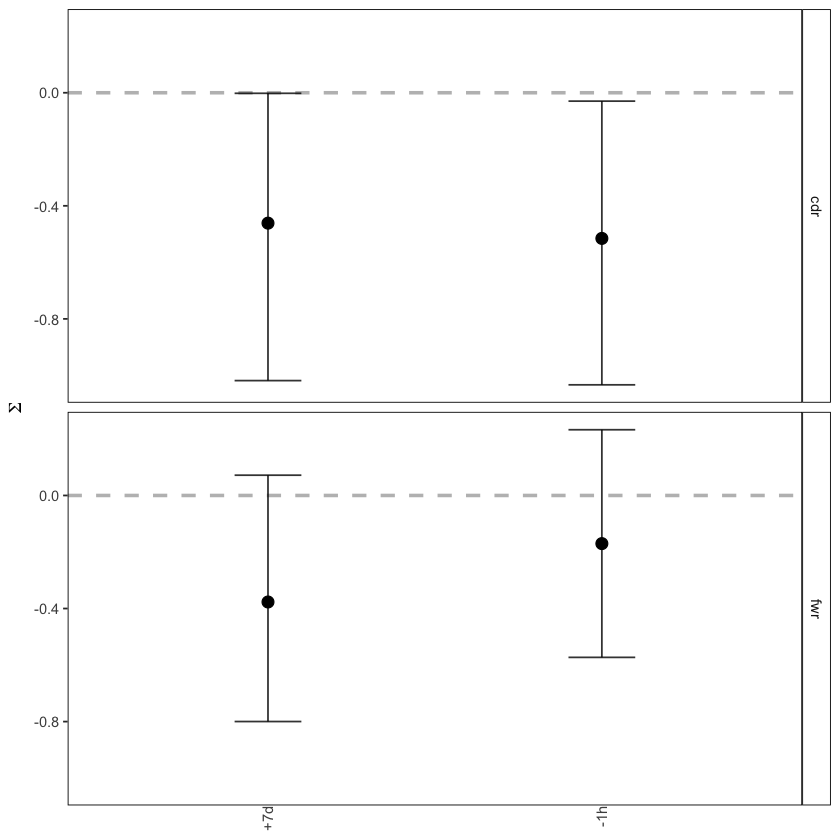

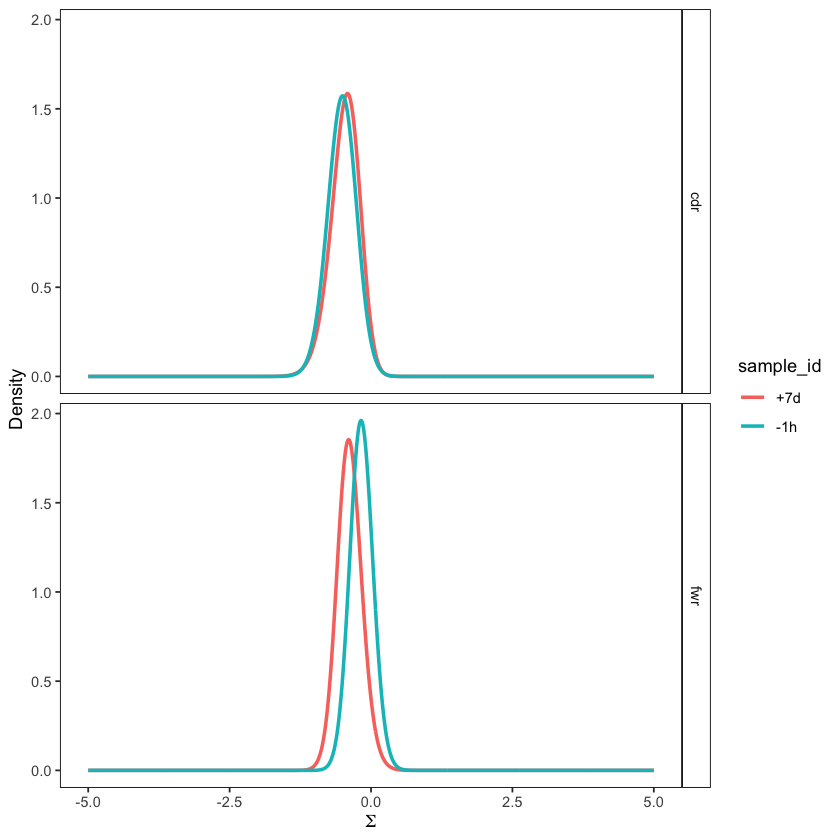

In [3]:
# BASELINE MODEL SHAZAM

# 1. Cargar repertorio AIRR-compliant
data(ExampleDb, package="alakazam")

# Filtrar por isotipos de interés(cambiar dependiendo del repertorio)
db <- subset(ExampleDb, c_call %in% c("IGHM","IGHD"))

# 2. Colapsar clones a secuencia consenso
clones <- collapseClones(
  db,
  cloneColumn="clone_id",
  sequenceColumn="sequence_alignment",
  germlineColumn="germline_alignment_d_mask",
  regionDefinition=IMGT_V,
  method="thresholdedFreq",
  minimumFrequency=0.6,
  includeAmbiguous=FALSE,
  breakTiesStochastic=FALSE,
  nproc=1
)

# 3. Calcular selección (observed + expected + baseline en un paso)
baseline <- calcBaseline(
  clones,
  testStatistic="focused",       # estadístico recomendado
  regionDefinition=IMGT_V,       # regiones CDR/FWR
  targetingModel=HH_S5F,         # modelo humano 5-mer por defecto
  nproc=1
)

# 4. Agrupar PDFs de selección por anotación (ej. sample_id)
grouped <- groupBaseline(baseline, groupBy="sample_id")

# 5. Visualizar resultados
plotBaselineSummary(grouped, idColumn="sample_id")
plotBaselineDensity(grouped, idColumn="sample_id")
